# Experiment 2: Training Dynamics and Hedge Quality

This notebook investigates how different training configurations affect the quality of Snowball hedging. We'll compare various training epoch schedules and analyze the convergence behavior.

## Objectives
- Compare different training epoch schedules
- Analyze hedger price convergence
- Examine PnL distributions at different training stages
- Understand the impact of training duration on hedge quality

In [1]:
# Import all necessary libraries
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from math import sqrt

# PfHedge imports
from pfhedge.instruments import LocalVolatilityStock, BrownianStock,Snowball
from pfhedge.nn.modules.hedger import Hedger
from pfhedge.nn.modules.loss import EntropicRiskMeasure
from pfhedge.nn.modules.mlp import MultiLayerPerceptron
# 添加中证500数据处理的导入
from datetime import datetime, timedelta
from matplotlib.font_manager import FontProperties
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 或者使用 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False    # 正确显示负号

# Set random seed for reproducibility
torch.manual_seed(42)
print("Training dynamics experiment loaded successfully!")

Training dynamics experiment loaded successfully!


In [2]:
def create_basic_snowball():
    """Create a basic Snowball option for experimentation."""

    # Market parameters
    init_state = 100.0
    dt = 1 / 250  # Daily time steps
    sigma = 0.2
    mu = 0.0
    cost = 1e-4

    # Underlying stock
    stock = BrownianStock(sigma=sigma, mu=mu, dt=dt, cost=cost)

    # Observation dates (monthly observations over 1 year)
    obs_days = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210, 230, 250]

    # Snowball parameters
    derivative = Snowball(
        underlier=stock,
        notional=100.0,
        init_spot=init_state,
        strike=100.0,
        maturity=obs_days[-1] * dt,
        knockin_barrier=80.0,  # 20% below initial spot
        observations=[d * dt for d in obs_days],
        knockout_barriers=[100.0] * len(obs_days),  # At-the-money knock-out
        knockout_coupons=[0.5 * d / 250 for d in obs_days],  # Time-proportional coupons
        no_touch_coupon=0.05,  # 5% if never knocked out
        is_knocked_in=False,
    )

    return derivative, stock, init_state

Training Dynamics Experiment
Training hedger with progressive snapshots...


Loss=5.2600: 100%|██████████| 100/100 [10:50<00:00,  6.50s/it]


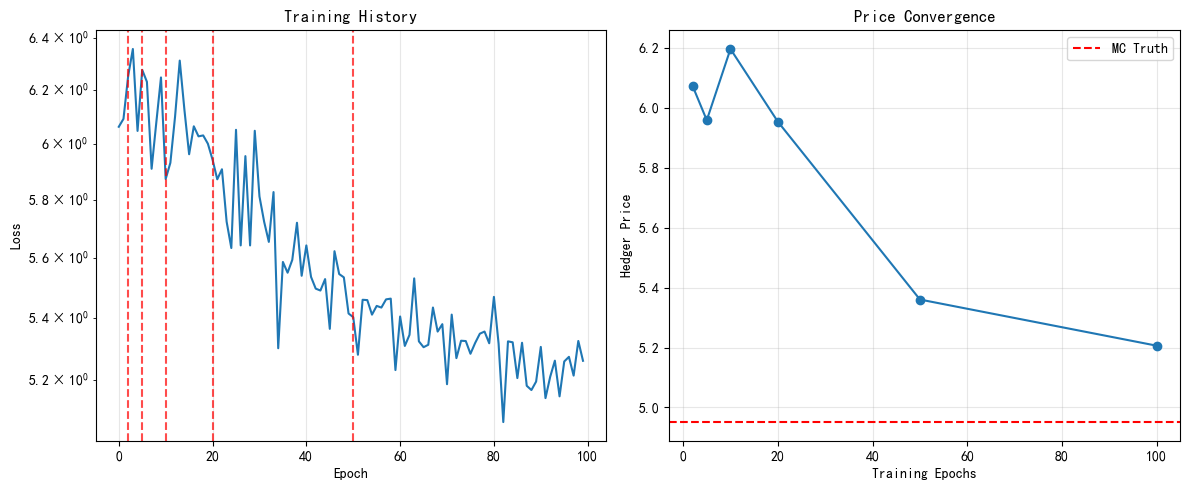


PnL Distribution Analysis:
------------------------------
2 epochs - Mean PnL: -5.089116, Std PnL: 15.644217
5 epochs - Mean PnL: -5.087289, Std PnL: 15.437864
10 epochs - Mean PnL: -5.084230, Std PnL: 15.098253
20 epochs - Mean PnL: -5.078074, Std PnL: 14.286603
50 epochs - Mean PnL: -5.038261, Std PnL: 9.702365
100 epochs - Mean PnL: -5.024219, Std PnL: 6.551488


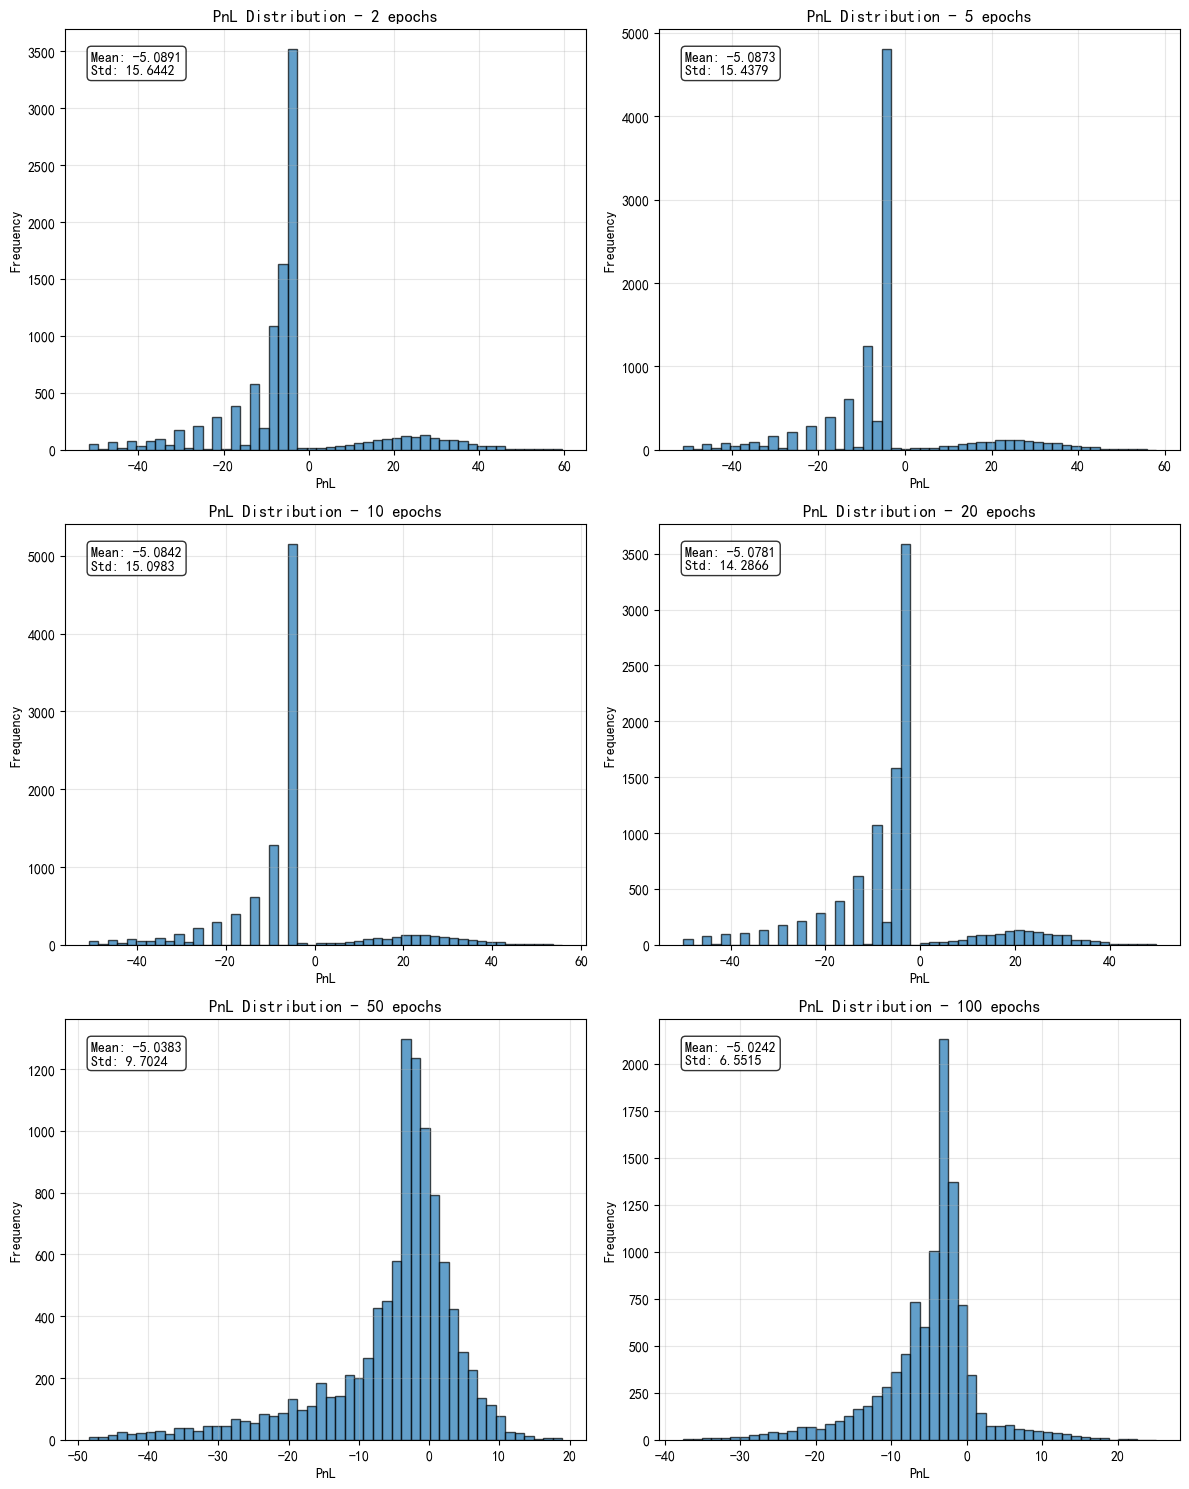

In [3]:
def training_dynamics_experiment():
    """Experiment with different training dynamics for Snowball hedging."""

    print("Training Dynamics Experiment")
    print("=" * 50)

    # Create derivative
    derivative, stock, init_state = create_basic_snowball()

    # Training parameters
    fit_n_paths = 10000
    fit_n_epochs = [2, 5, 10, 20, 50, 100]
    loss = EntropicRiskMeasure(a=0.01)

    # Features for Snowball hedging
    features = [
        "log_moneyness",     # Current underlying price relative to strike
        "expiry_time",       # Time to expiration
        "volatility",        # Implied volatility
        "knocked_in",        # Whether barrier has been touched
        "prev_hedge"         # Previous hedge position
    ]

    # Create hedger
    hedger = Hedger(
        MultiLayerPerceptron(n_layers=4, n_units=[32, 32, 32, 32]),
        features,
        criterion=loss,
    )

    # Fit hedger with snapshots
    init_spot = torch.tensor(init_state, requires_grad=True)

    print("Training hedger with progressive snapshots...")
    history, hedgers = hedger.fit(
        derivative,
        n_epochs=fit_n_epochs[-1],
        n_paths=fit_n_paths,
        init_state=(init_spot,),
        snapshots=fit_n_epochs[:-1],
    )

    # Get baseline PV for comparison
    # Quick valuation
    derivative.simulate(n_paths=100000, init_state=(init_spot,))
    pv_basic = derivative.payoff().mean().item()

    # Plot training history
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training History")
    plt.yscale('log')
    plt.grid(True, alpha=0.3)

    # Mark snapshot points
    for epoch in fit_n_epochs[:-1]:
        plt.axvline(x=epoch, color='red', linestyle='--', alpha=0.7)

    # Evaluate hedger price at different training stages
    prices = []
    for h in hedgers:
        price = h.price(derivative, n_paths=50000, init_state=(init_spot,))
        prices.append(price.item())

    plt.subplot(1, 2, 2)
    plt.plot(fit_n_epochs, prices, 'o-')
    plt.axhline(y=pv_basic, color='red', linestyle='--', label='MC Truth')
    plt.xlabel("Training Epochs")
    plt.ylabel("Hedger Price")
    plt.title("Price Convergence")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Analyze PnL distributions
    print("\nPnL Distribution Analysis:")
    print("-" * 30)

    # Test PnL for different training stages
    derivative.simulate(n_paths=fit_n_paths, init_state=(init_spot,))
    pnls = [h.compute_pl(derivative) for h in hedgers]

    # Plot PnL distributions
    n_row = (len(pnls) + 1) // 2
    fig, axes = plt.subplots(n_row, 2, figsize=(12, 5 * n_row))
    axes = axes.flatten() if n_row > 1 else [axes] if n_row == 1 else axes

    for i, (pnl, epochs) in enumerate(zip(pnls, fit_n_epochs)):
        ax = axes[i]
        ax.hist(pnl.detach().numpy(), bins=50, alpha=0.7, edgecolor='black')
        ax.set_xlabel("PnL")
        ax.set_ylabel("Frequency")
        ax.set_title(f"PnL Distribution - {epochs} epochs")
        ax.grid(True, alpha=0.3)

        # Add statistics
        mean_pnl = pnl.mean().item()
        std_pnl = pnl.std().item()
        ax.text(0.05, 0.95, f'Mean: {mean_pnl:.4f}\nStd: {std_pnl:.4f}',
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        print(f"{epochs} epochs - Mean PnL: {mean_pnl:.6f}, Std PnL: {std_pnl:.6f}")

    # Hide empty subplots
    for i in range(len(pnls), len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()

    return hedgers, history

# Run training dynamics experiment
hedgers_basic, history_basic = training_dynamics_experiment()

中证500历史数据回测 - 局部波动率模型（使用预训练对冲器）
数据时间范围: 2020-03-11 00:00:00 到 2025-03-07 00:00:00
总交易日数: 1210
局部波动率参数 - μ: 0.0091, σ₀: 0.1957
初始价格: 5589.53
使用预训练对冲器（训练100个epoch）
蒙特卡洛价格: -0.018618
对冲器价格: 4099.698242
价格差异: 4099.716860


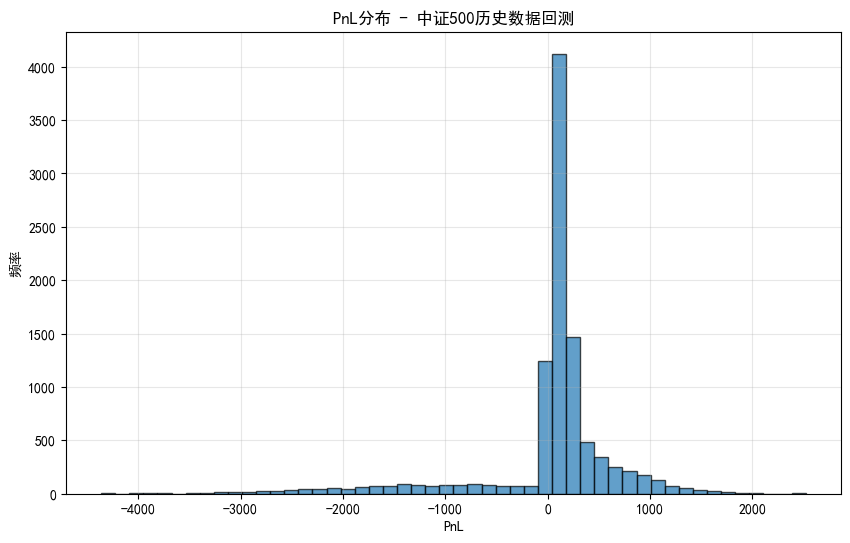


回测统计:
------------------------------
PnL均值: 25.013573
PnL标准差: 695.632690
最大盈利: 2519.591553
最大亏损: -4362.188477
VaR(95%): -1579.809326


In [4]:
# 添加必要的导入
from pfhedge.instruments import BrownianStock
from datetime import datetime, timedelta

def load_csi500_data():
    """加载中证500历史数据"""
    df = pd.read_csv('csi500.csv')
    df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d')
    df = df.sort_values('Date').reset_index(drop=True)
    
    # 计算日收益率和波动率
    df['Returns'] = df['Close'].pct_change()
    df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))
    df['Volatility'] = df['Returns'].rolling(window=20).std() * np.sqrt(252)
    
    return df

def create_csi500_snowball_lv(df, start_date, end_date):
    """基于中证500数据创建Snowball期权（使用局部波动率模型）"""
    
    # 筛选时间范围
    mask = (df['Date'] >= start_date) & (df['Date'] <= end_date)
    period_data = df[mask].copy()
    
    if len(period_data) < 250:
        return None, None, None, None
    
    # 计算局部波动率参数
    init_price = period_data.iloc[0]['Close']
    returns = period_data['Returns'].dropna()
    mu = returns.mean() * 252  # 年化收益率
    sigma= returns.std() * np.sqrt(252)  # 年化波动率
    
    print(f"局部波动率参数 - μ: {mu:.4f}, σ₀: {sigma:.4f}")
    
    # 定义局部波动率函数（基于中证500数据）
    def sigma_fn_lv(time: torch.Tensor, spot: torch.Tensor) -> torch.Tensor:
        beta = 0.5  # CEV参数
        moneyness = spot / init_price
        return sigma* (moneyness ** (beta - 1)).clamp(min=0.01, max=1.0)
    
    # 创建局部波动率股票模型
    stock = BrownianStock(sigma=sigma, mu=mu, dt=1/252, cost=1e-4)
    
    # 设置观察日期（每月观察）
    obs_days = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210, 230, 250]
    
    # 创建Snowball期权
    derivative = Snowball(
        underlier=stock,
        notional=1.0,
        init_spot=init_price,
        strike=init_price,
        maturity=obs_days[-1] * (1/252),
        knockin_barrier=init_price * 0.8,
        observations=[d * (1/252) for d in obs_days],
        knockout_barriers=[init_price] * len(obs_days),
        knockout_coupons=[0.05 * d / 250 for d in obs_days],
        no_touch_coupon=0.05,
        is_knocked_in=False,
    )
    
    return derivative, stock, init_price, period_data

def backtest_snowball_on_csi500_lv():
    """在中证500历史数据上回测Snowball期权（使用预训练的局部波动率对冲器）"""
    
    print("中证500历史数据回测 - 局部波动率模型（使用预训练对冲器）")
    print("=" * 50)
    
    # 检查是否有预训练的对冲器 - 修正变量名
    if 'hedgers_basic' not in globals():
        print("错误：没有找到预训练的对冲器，请先运行前面的训练")
        return None, None, None
    
    # 加载数据
    df = load_csi500_data()
    print(f"数据时间范围: {df['Date'].min()} 到 {df['Date'].max()}")
    print(f"总交易日数: {len(df)}")
    
    # 设置回测参数
    start_date = pd.to_datetime('2020-03-01')
    end_date = pd.to_datetime('2024-03-01')
    
    # 创建Snowball期权
    derivative, stock, init_price, period_data = create_csi500_snowball_lv(df, start_date, end_date)
    
    if derivative is None:
        print("数据不足，无法创建期权")
        return None, None, None
    
    print(f"初始价格: {init_price:.2f}")
    
    # 使用预训练的对冲器（取最后一个，即训练100个epoch的）
    hedger = hedgers_basic[-1]  # 使用训练100个epoch的对冲器
    print(f"使用预训练对冲器（训练100个epoch）")
    
    # 测试对冲器
    init_spot = torch.tensor(init_price, requires_grad=True)
    
    # 计算期权价格
    derivative.simulate(n_paths=50000, init_state=(init_spot,))
    mc_price = derivative.payoff().mean().item()
    hedger_price = hedger.price(derivative, n_paths=50000, init_state=(init_spot,)).item()
    
    print(f"蒙特卡洛价格: {mc_price:.6f}")
    print(f"对冲器价格: {hedger_price:.6f}")
    print(f"价格差异: {abs(mc_price - hedger_price):.6f}")
    
    # 计算PnL分布
    derivative.simulate(n_paths=10000, init_state=(init_spot,))
    pnl = hedger.compute_pl(derivative)
    
    # 只绘制PnL分布图
    plt.figure(figsize=(10, 6))
    plt.hist(pnl.detach().numpy(), bins=50, alpha=0.7, edgecolor='black')
    plt.xlabel("PnL")
    plt.ylabel("频率")
    plt.title("PnL分布 - 中证500历史数据回测")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # 统计信息
    print("\n回测统计:")
    print("-" * 30)
    print(f"PnL均值: {pnl.mean().item():.6f}")
    print(f"PnL标准差: {pnl.std().item():.6f}")
    print(f"最大盈利: {pnl.max().item():.6f}")
    print(f"最大亏损: {pnl.min().item():.6f}")
    print(f"VaR(95%): {torch.quantile(pnl, 0.05).item():.6f}")
    
    return hedger, derivative, period_data

# 运行回测
hedger_csi500, derivative_csi500, data_csi500 = backtest_snowball_on_csi500_lv()

开始模型比较分析...
尝试读取文件: csi500.csv
文件是否存在: True
原始数据长度: 1210
筛选后数据长度: 242
使用的时间范围: 2023-11-16 到 2024-11-15
模拟的价格路径长度: 242 天
LV路径范围: 79.35 - 112.86
GBM路径范围: 79.35 - 112.86
路径相关性: 1.0000
使用预训练对冲器（训练100个epoch）
LV深度对冲计算完成，长度: 242
GBM深度对冲计算完成，长度: 242
Delta对冲计算完成，长度: 243
Deep Hedging (LV): 已修正最后一日PnL
Deep Hedging (GBM): 已修正最后一日PnL
Delta Hedge: 已修正最后一日PnL


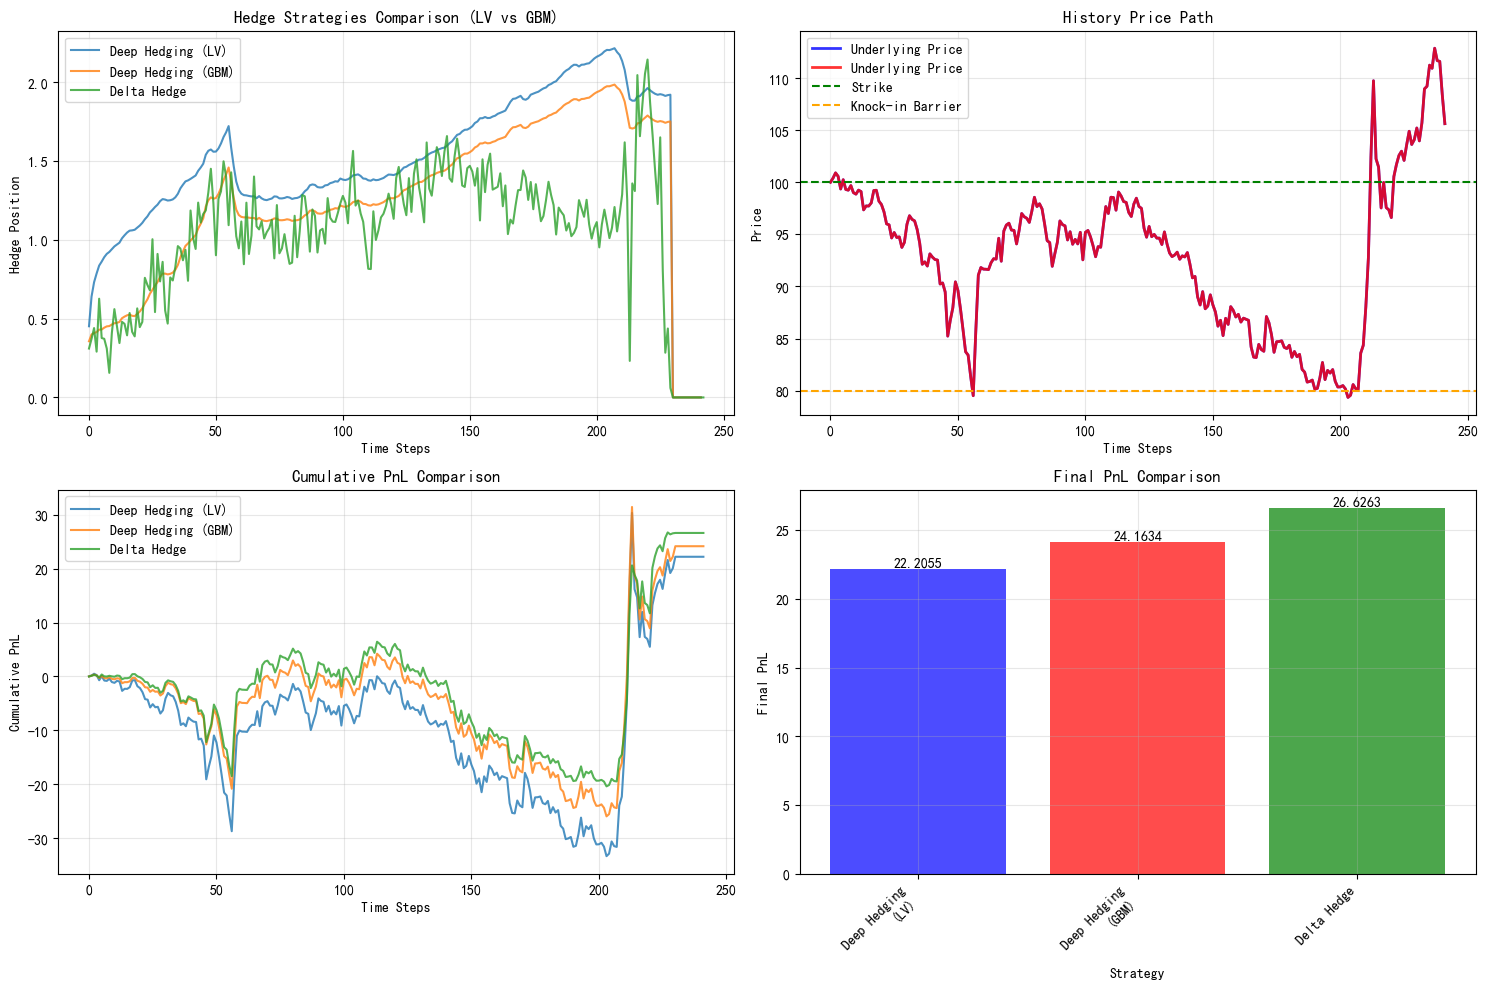


Model Comparison Summary:
----------------------------------------
Deep Hedging (LV): Final PnL = 22.205507
Deep Hedging (GBM): Final PnL = 24.163441
Delta Hedge: Final PnL = 26.626347

Model Performance Analysis:
----------------------------------------
Local Volatility vs GBM improvement: -1.957933
Improvement percentage: -8.10%


In [24]:
def compare_lv_vs_gbm_models():
    """比较局部波动率模型和GBM模型在历史数据上的表现"""
    
    print("开始模型比较分析...")
    
    # 检查是否有预训练的对冲器
    if 'hedgers_basic' not in globals():
        print("错误：没有找到预训练的对冲器，请先运行前面的训练")
        return None
    
    # 1. 加载历史数据 - 使用指定时间范围
    csv_path = "csi500.csv"
    print(f"尝试读取文件: {csv_path}")
    print(f"文件是否存在: {os.path.exists(csv_path)}")

    try:
        quotes = pd.read_csv(csv_path)
        print(f"原始数据长度: {len(quotes)}")
        
        # 转换日期格式
        quotes['Date'] = pd.to_datetime(quotes['Date'], format='%Y%m%d')
        
        # 筛选指定时间范围：2023-11-16到2024-11-16
        start_date = pd.to_datetime('2023-11-16')
        end_date = pd.to_datetime('2024-11-16')
        
        mask = (quotes['Date'] >= start_date) & (quotes['Date'] <= end_date)
        period_quotes = quotes[mask].copy()
        
        if len(period_quotes) == 0:
            print("指定时间范围内没有数据，使用默认数据")
            series = torch.randn(251).cumsum(0).exp()
        else:
            series = torch.tensor(period_quotes["Close"].values, dtype=torch.float)
            print(f"筛选后数据长度: {len(series)}")
            print(f"使用的时间范围: {period_quotes['Date'].iloc[0].date()} 到 {period_quotes['Date'].iloc[-1].date()}")
        
    except Exception as e:
        print(f"Market data not available, using synthetic data. Error: {e}")
        series = torch.randn(251).cumsum(0).exp()
    
    # 2. 创建基于历史数据的局部波动率函数
    def historical_sigma_fn(time: torch.Tensor, spot: torch.Tensor) -> torch.Tensor:
        """基于历史数据的局部波动率函数 - 保留局部波动率特性"""
        if not isinstance(spot, torch.Tensor):
            spot = torch.tensor(spot, dtype=torch.float32)
        if not isinstance(time, torch.Tensor):
            time = torch.tensor(time, dtype=torch.float32)
        
        # 计算历史波动率特征
        returns = torch.diff(torch.log(series))  # 对数收益率
        hist_vol = torch.std(returns) * torch.sqrt(torch.tensor(252.0))
        avg_price = torch.mean(series)
        
        # 局部波动率模型：基于价格水平的波动率调整
        moneyness = spot / avg_price
        log_moneyness = torch.log(moneyness)
        
        # CEV风格的局部波动率
        beta = 0.5
        sigma_0 = hist_vol
        local_vol = sigma_0 * (moneyness ** (beta - 1))
        
        # 添加微笑效应
        smile_effect = 1.0 + 0.2 * log_moneyness**2
        
        # 时间衰减效应
        time_effect = 1.0 + 0.1 * torch.exp(-time)
        
        final_vol = local_vol * smile_effect * time_effect
        return torch.clamp(final_vol, min=0.05, max=0.8)
    
    # 3. 创建历史路径股票类（保留局部波动率）
    class HistoricalLocalVolStock:
        def __init__(self, historical_prices, sigma_fn):
            self.historical_prices = historical_prices
            self.sigma_fn = sigma_fn
            self.dt = 1/252
            self.cost = 1e-4
            self.spot = None
            self.volatility = None
            self.log_spot = None
            
        def simulate(self, n_paths, time_horizon=None, init_state=None):
            """使用历史路径进行模拟，保留局部波动率计算"""
            if init_state is None:
                init_state = (100.0,)
            
            n_steps = len(self.historical_prices)
            spot = torch.zeros(n_paths, n_steps)
            volatility = torch.zeros(n_paths, n_steps)
            
            # 将历史价格标准化到100为基准
            price_scale = 100.0 / self.historical_prices[0]
            normalized_prices = self.historical_prices * price_scale
            
            # 使用标准化后的历史路径
            for i in range(n_steps):
                spot[:, i] = normalized_prices[i]
                
                # 计算局部波动率
                time = i * self.dt
                current_spot = spot[:, i]
                sigma = self.sigma_fn(torch.tensor(time), current_spot)
                volatility[:, i] = sigma
            
            self.spot = spot
            self.volatility = volatility
            self.log_spot = torch.log(spot)
            return self
        
        def is_listed(self, time: float) -> bool:
            return True
        
        def to(self, device=None, dtype=None, non_blocking=False):
            if self.spot is not None:
                self.spot = self.spot.to(device, dtype, non_blocking)
            if self.volatility is not None:
                self.volatility = self.volatility.to(device, dtype, non_blocking)
            if self.log_spot is not None:
                self.log_spot = self.log_spot.to(device, dtype, non_blocking)
            return self
    
    # 4. 创建历史路径股票类（GBM - 使用相同的历史数据）
    class HistoricalGBMStock:
        def __init__(self, historical_prices):
            self.historical_prices = historical_prices
            self.dt = 1/252
            self.cost = 1e-4
            self.spot = None
            self.volatility = None
            self.log_spot = None
            
        def simulate(self, n_paths, time_horizon=None, init_state=None):
            """使用历史路径进行模拟，但使用固定波动率（GBM）"""
            if init_state is None:
                init_state = (100.0,)
            
            n_steps = len(self.historical_prices)
            spot = torch.zeros(n_paths, n_steps)
            
            # 计算历史波动率（固定值，用于GBM）
            returns = torch.diff(torch.log(self.historical_prices))
            hist_vol = torch.std(returns) * torch.sqrt(torch.tensor(252.0))
            
            # 将历史价格标准化到100为基准
            price_scale = 100.0 / self.historical_prices[0]
            normalized_prices = self.historical_prices * price_scale
            
            # 使用标准化后的历史路径（与局部波动率模型使用相同的历史路径）
            for i in range(n_steps):
                spot[:, i] = normalized_prices[i]
            
            self.spot = spot
            # GBM使用固定波动率
            self.volatility = torch.full_like(spot, hist_vol)
            self.log_spot = torch.log(spot)
            return self
        
        def is_listed(self, time: float) -> bool:
            return True
        
        def to(self, device=None, dtype=None, non_blocking=False):
            if self.spot is not None:
                self.spot = self.spot.to(device, dtype, non_blocking)
            if self.volatility is not None:
                self.volatility = self.volatility.to(device, dtype, non_blocking)
            if self.log_spot is not None:
                self.log_spot = self.log_spot.to(device, dtype, non_blocking)
            return self
    
    # 5. 创建历史路径股票（局部波动率）
    historical_stock_lv = HistoricalLocalVolStock(series, historical_sigma_fn)
    
    # 6. 创建历史路径股票（GBM - 使用相同的历史数据）
    historical_stock_gbm = HistoricalGBMStock(series)
    
    # 7. 创建雪球期权 - 根据实际数据长度调整观察日
    n_days = len(series)
    obs_days = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210, 230, 250]
    obs_days = [d for d in obs_days if d <= n_days]  # 确保不超过实际天数
    
    # 局部波动率模型的期权
    derivative_lv = Snowball(
        underlier=historical_stock_lv,
        notional=100.0,
        init_spot=100.0,
        strike=100.0,
        maturity=n_days * (1/252),
        knockin_barrier=80.0,
        observations=[d * (1/252) for d in obs_days],
        knockout_barriers=[100.0] * len(obs_days),
        knockout_coupons=[0.5 * d / 250 for d in obs_days],
        no_touch_coupon=0.05,
        is_knocked_in=False,
    )
    
    # GBM模型的期权
    derivative_gbm = Snowball(
        underlier=historical_stock_gbm,
        notional=100.0,
        init_spot=100.0,
        strike=100.0,
        maturity=n_days * (1/252),
        knockin_barrier=80.0,
        observations=[d * (1/252) for d in obs_days],
        knockout_barriers=[100.0] * len(obs_days),
        knockout_coupons=[0.5 * d / 250 for d in obs_days],
        no_touch_coupon=0.05,
        is_knocked_in=False,
    )
    
    # 8. 生成测试路径
    init_spot = torch.tensor(100.0, requires_grad=True)
    
    # 局部波动率模型路径
    derivative_lv.simulate(n_paths=1, init_state=(init_spot,))
    spots_lv = derivative_lv.ul().spot.squeeze().detach().numpy()
    
    # GBM模型路径 - 使用相同的历史数据
    derivative_gbm.simulate(n_paths=1, init_state=(init_spot,))
    spots_gbm = derivative_gbm.ul().spot.squeeze().detach().numpy()
    
    print(f"模拟的价格路径长度: {len(spots_lv)} 天")
    print(f"LV路径范围: {spots_lv.min():.2f} - {spots_lv.max():.2f}")
    print(f"GBM路径范围: {spots_gbm.min():.2f} - {spots_gbm.max():.2f}")
    print(f"路径相关性: {np.corrcoef(spots_lv, spots_gbm)[0,1]:.4f}")
    
    # 9. 计算各策略的hedge路径和PnL
    hedge_paths, pnl_paths = {}, {}
    
    # 使用预训练的对冲器（取最后一个，即训练100个epoch的）
    hedger = hedgers_basic[-1]
    print(f"使用预训练对冲器（训练100个epoch）")
    
    try:
        # 局部波动率模型的深度对冲策略
        hedge_lv = hedger.compute_hedge(derivative_lv).squeeze()
        pnl_lv = hedger.compute_cum_pl(derivative_lv).squeeze()
        hedge_paths['Deep Hedging (LV)'] = hedge_lv.detach().numpy()
        pnl_paths['Deep Hedging (LV)'] = pnl_lv.detach().numpy()
        print(f"LV深度对冲计算完成，长度: {len(hedge_paths['Deep Hedging (LV)'])}")
        
        # GBM模型的深度对冲策略
        hedge_gbm = hedger.compute_hedge(derivative_gbm).squeeze()
        pnl_gbm = hedger.compute_cum_pl(derivative_gbm).squeeze()
        hedge_paths['Deep Hedging (GBM)'] = hedge_gbm.detach().numpy()
        pnl_paths['Deep Hedging (GBM)'] = pnl_gbm.detach().numpy()
        print(f"GBM深度对冲计算完成，长度: {len(hedge_paths['Deep Hedging (GBM)'])}")
        
        # Delta对冲策略（用于对比）- 使用修复后的函数
        delta_hedge_positions, delta_pvs = compute_delta_hedge(derivative_lv, spots_lv)
        hedge_paths['Delta Hedge'] = delta_hedge_positions
        print(f"Delta对冲计算完成，长度: {len(delta_hedge_positions)}")
        
        # 保证长度匹配
        min_len = min(len(delta_hedge_positions), len(spots_lv))
        delta_hedge_positions = delta_hedge_positions[:min_len]
        delta_pvs = delta_pvs[:min_len]
        spots_adj = spots_lv[:min_len]
        
        from pfhedge.nn.functional import cum_pl
        delta_hedge_pnl = cum_pl(
            torch.tensor(spots_adj).unsqueeze(0).unsqueeze(0),
            torch.tensor(delta_hedge_positions).unsqueeze(0).unsqueeze(0),
            cost=[1e-4],
            payoff=derivative_lv.payoff(),
        ).squeeze().detach().numpy()
        pnl_paths['Delta Hedge'] = delta_hedge_pnl
        
        # 消除所有策略最后一日的大跳水
        for strategy_name in pnl_paths.keys():
            if len(pnl_paths[strategy_name]) > 1:
                pnl_paths[strategy_name][-1] = pnl_paths[strategy_name][-2]
                print(f"{strategy_name}: 已修正最后一日PnL")
        
    except Exception as e:
        print(f"Error computing hedge: {e}")
        import traceback
        traceback.print_exc()
    
    # 10. 可视化 - 四宫格比较图
    plt.figure(figsize=(15, 10))
    
    # 左上：对冲头寸比较
    plt.subplot(2, 2, 1)
    for name, hedge in hedge_paths.items():
        plt.plot(hedge, label=name, alpha=0.8)
    plt.xlabel("Time Steps")
    plt.ylabel("Hedge Position")
    plt.title("Hedge Strategies Comparison (LV vs GBM)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 右上：价格路径比较
    plt.subplot(2, 2, 2)
    plt.plot(spots_lv, label="Underlying Price", color='blue', linewidth=2, alpha=0.8)
    plt.plot(spots_gbm, label="Underlying Price", color='red', linewidth=2, alpha=0.8)
    plt.axhline(y=100, color='green', linestyle='--', label='Strike')
    plt.axhline(y=80, color='orange', linestyle='--', label='Knock-in Barrier')
    plt.xlabel("Time Steps")
    plt.ylabel("Price")
    plt.title("History Price Path")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 左下：累积PnL比较
    plt.subplot(2, 2, 3)
    for name, pnl in pnl_paths.items():
        plt.plot(pnl, label=name, alpha=0.8)
    plt.xlabel("Time Steps")
    plt.ylabel("Cumulative PnL")
    plt.title("Cumulative PnL Comparison")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 右下：最终PnL对比
    plt.subplot(2, 2, 4)
    final_pnls = [pnl[-1] for pnl in pnl_paths.values()]
    strategy_names_short = list(pnl_paths.keys())
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    bars = plt.bar(range(len(final_pnls)), final_pnls,
                   color=colors[:len(final_pnls)], alpha=0.7)
    plt.xlabel("Strategy")
    plt.ylabel("Final PnL")
    plt.title("Final PnL Comparison")
    plt.xticks(range(len(strategy_names_short)),
               [name.replace(' (', '\n(') for name in strategy_names_short],
               rotation=45, ha='right')
    plt.grid(True, alpha=0.3)
    for bar, value in zip(bars, final_pnls):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{value:.4f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # 11. 打印统计信息
    print("\nModel Comparison Summary:")
    print("-" * 40)
    for name, pnl in pnl_paths.items():
        print(f"{name}: Final PnL = {pnl[-1]:.6f}")
    
    # 12. 模型性能对比
    print("\nModel Performance Analysis:")
    print("-" * 40)
    if 'Deep Hedging (LV)' in pnl_paths and 'Deep Hedging (GBM)' in pnl_paths:
        lv_pnl = pnl_paths['Deep Hedging (LV)'][-1]
        gbm_pnl = pnl_paths['Deep Hedging (GBM)'][-1]
        improvement = lv_pnl - gbm_pnl
        print(f"Local Volatility vs GBM improvement: {improvement:.6f}")
        print(f"Improvement percentage: {(improvement/gbm_pnl)*100:.2f}%")
    
    return hedge_paths, pnl_paths

# 运行模型比较分析
comparison_result = compare_lv_vs_gbm_models()

创建测试数据...
使用模拟数据：250天，价格范围：76.30-109.38
计算正确的PVS变化曲线...
开始计算正确的PVS变化曲线...
第0天 PVS: -5.096981
第50天 PVS: -21.401219
第100天 PVS: -22.311679
第150天 PVS: -22.175062
第200天 PVS: -15.030377


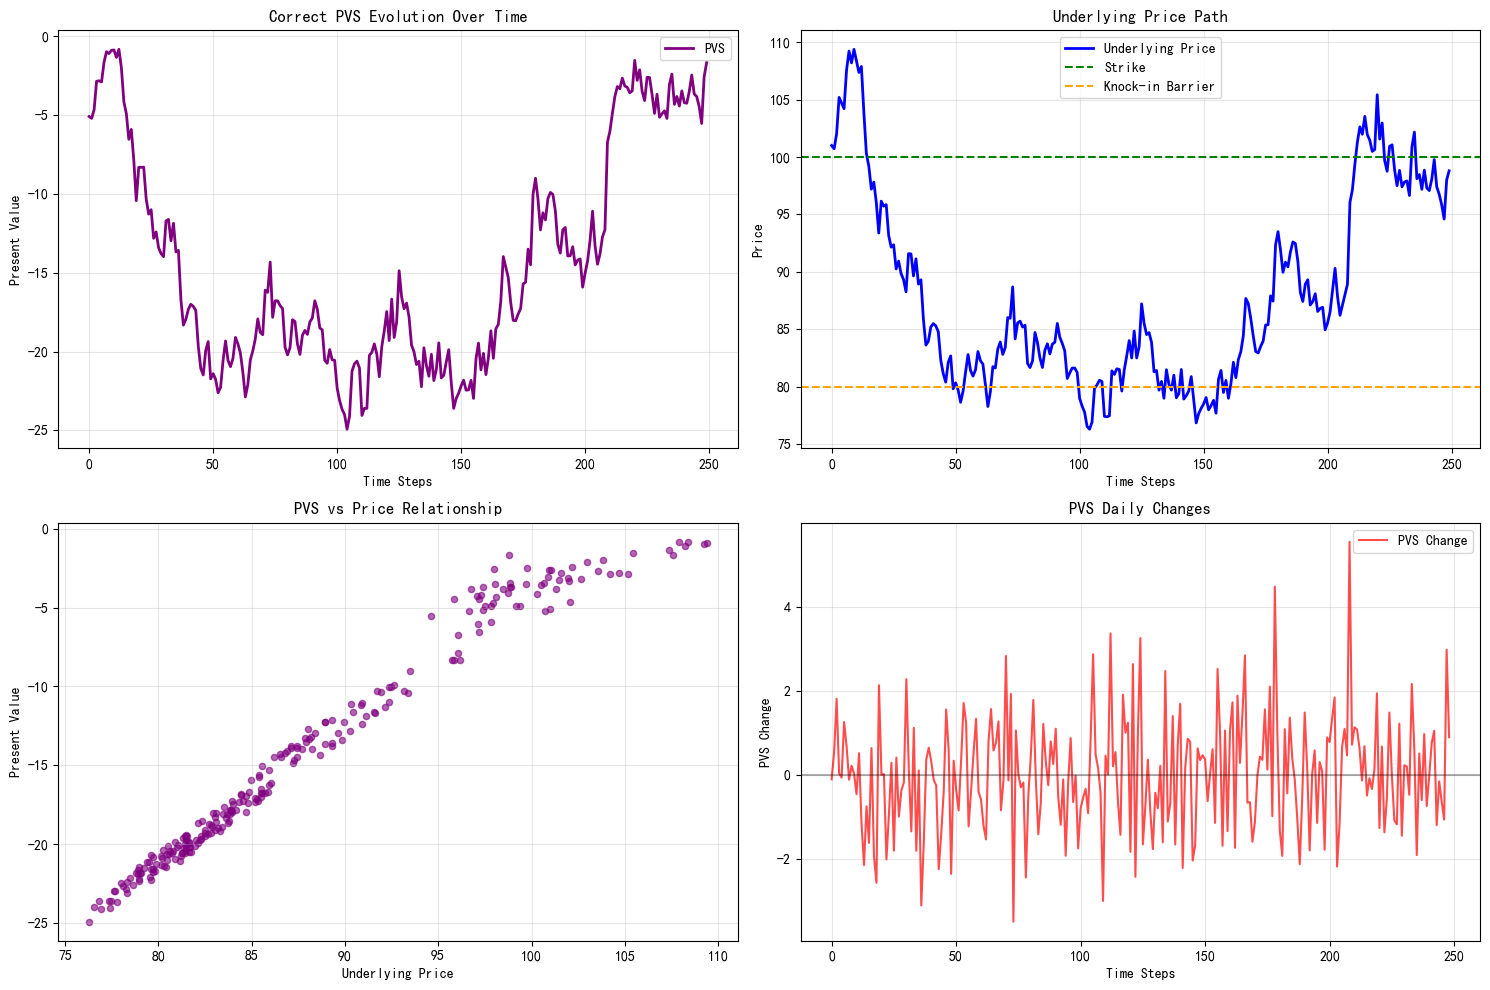


PVS Statistics:
----------------------------------------
Initial PVS: -5.096981
Final PVS: -1.678063
Max PVS: -0.832001
Min PVS: -24.924449
PVS Volatility: 6.970972
PVS Range: 24.092448

PVS合理性检查:
----------------------------------------
PVS为0的天数: 0
PVS为负数的天数: 250
PVS为正数的天数: 0

PVS变化模式:
----------------------------------------
PVS上升天数: 126
PVS下降天数: 123
PVS不变天数: 0


In [29]:
def calculate_correct_pvs_curve(spots, derivative, obs_days, n_paths=10000):
    """正确计算PVS变化曲线"""
    
    print("开始计算正确的PVS变化曲线...")
    
    # 获取原始期权参数
    notional = derivative.notional
    strike = derivative.strike
    knockin_barrier = derivative.knockin_barrier
    knockout_barriers = derivative.knockout_barriers
    knockout_coupons = derivative.knockout_coupons
    no_touch_coupon = derivative.no_touch_coupon
    
    pvs_curve = []
    
    for i in range(len(spots)):
        current_spot = spots[i]
        remaining_days = len(spots) - i
        
        if remaining_days <= 0:
            pvs_curve.append(0.0)
            continue
            
        # 检查当前状态
        is_knocked_in = False
        is_knocked_out = False
        
        # 检查历史路径中的敲入敲出状态
        for j in range(i):
            if spots[j] <= knockin_barrier:
                is_knocked_in = True
            if j in obs_days and spots[j] > knockout_barriers[obs_days.index(j)]:
                is_knocked_out = True
                break
        
        if is_knocked_out:
            # 已经敲出，PVS为0
            pvs_curve.append(0.0)
            continue
        
        # 计算剩余观察日
        remaining_obs_days = [d for d in obs_days if d > i]
        if not remaining_obs_days:
            # 没有剩余观察日，计算最终支付
            if is_knocked_in:
                final_payoff = max(0, strike - spots[-1]) if spots[-1] < strike else 0
                pvs_curve.append(-final_payoff)  # 负号因为是对冲方
            else:
                pvs_curve.append(-no_touch_coupon)  # 负号因为是对冲方
            continue
        
        # 使用Monte Carlo计算PVS
        payoffs = []
        
        for _ in range(n_paths):
            # 模拟剩余路径
            remaining_spots = [current_spot]
            temp_knocked_in = is_knocked_in
            temp_knocked_out = False
            payoff = 0
            
            # 模拟剩余天数
            for day in range(1, remaining_days + 1):
                # 简单的随机游走（可以改进为更复杂的模型）
                daily_return = np.random.normal(0, 0.02)  # 2%日波动率
                new_spot = remaining_spots[-1] * (1 + daily_return)
                remaining_spots.append(new_spot)
                
                # 检查敲入
                if new_spot <= knockin_barrier:
                    temp_knocked_in = True
                
                # 检查敲出
                if (i + day) in remaining_obs_days:
                    obs_index = obs_days.index(i + day)
                    if new_spot > knockout_barriers[obs_index]:
                        temp_knocked_out = True
                        payoff = -knockout_coupons[obs_index]  # 负号因为是对冲方
                        break
            
            # 如果没有敲出，计算最终支付
            if not temp_knocked_out:
                if temp_knocked_in:
                    final_spot = remaining_spots[-1]
                    if final_spot < strike:
                        payoff = -(strike - final_spot)  # 负号因为是对冲方
                    else:
                        payoff = 0
                else:
                    payoff = -no_touch_coupon  # 负号因为是对冲方
            
            payoffs.append(payoff)
        
        # 计算PVS
        pvs = np.mean(payoffs)
        pvs_curve.append(pvs)
        
        if i % 50 == 0:
            print(f"第{i}天 PVS: {pvs:.6f}")
    
    return np.array(pvs_curve)

# 创建测试数据（如果spots_lv不存在）
if 'spots_lv' not in globals():
    print("创建测试数据...")
    # 生成模拟价格路径
    np.random.seed(42)
    n_days = 250
    spots_lv = 100 * np.exp(np.cumsum(np.random.normal(0, 0.02, n_days)))
    
    # 创建简单的期权参数
    obs_days = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210, 230, 250]
    obs_days = [d for d in obs_days if d <= n_days]
    
    # 创建临时期权对象（用于获取参数）
    class TempDerivative:
        def __init__(self):
            self.notional = 100.0
            self.strike = 100.0
            self.knockin_barrier = 80.0
            self.knockout_barriers = [100.0] * len(obs_days)
            self.knockout_coupons = [0.5 * d / 250 for d in obs_days]
            self.no_touch_coupon = 0.05
    
    derivative_lv = TempDerivative()
    
    print(f"使用模拟数据：{len(spots_lv)}天，价格范围：{spots_lv.min():.2f}-{spots_lv.max():.2f}")

# 计算正确的PVS曲线
print("计算正确的PVS变化曲线...")
correct_pvs_curve = calculate_correct_pvs_curve(
    spots=spots_lv, 
    derivative=derivative_lv, 
    obs_days=obs_days,
    n_paths=5000
)

# 可视化PVS变化
plt.figure(figsize=(15, 10))

# 上图：PVS变化曲线
plt.subplot(2, 2, 1)
plt.plot(correct_pvs_curve, label='PVS', color='purple', linewidth=2)
plt.xlabel("Time Steps")
plt.ylabel("Present Value")
plt.title("Correct PVS Evolution Over Time")
plt.legend()
plt.grid(True, alpha=0.3)

# 中上图：价格路径
plt.subplot(2, 2, 2)
plt.plot(spots_lv, label='Underlying Price', color='blue', linewidth=2)
plt.axhline(y=100, color='green', linestyle='--', label='Strike')
plt.axhline(y=80, color='orange', linestyle='--', label='Knock-in Barrier')
plt.xlabel("Time Steps")
plt.ylabel("Price")
plt.title("Underlying Price Path")
plt.legend()
plt.grid(True, alpha=0.3)

# 中下图：PVS与价格关系
plt.subplot(2, 2, 3)
plt.scatter(spots_lv, correct_pvs_curve, alpha=0.6, s=20, color='purple')
plt.xlabel("Underlying Price")
plt.ylabel("Present Value")
plt.title("PVS vs Price Relationship")
plt.grid(True, alpha=0.3)

# 下图：PVS变化率
plt.subplot(2, 2, 4)
pvs_changes = np.diff(correct_pvs_curve)
plt.plot(pvs_changes, label='PVS Change', color='red', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.xlabel("Time Steps")
plt.ylabel("PVS Change")
plt.title("PVS Daily Changes")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印PVS统计信息
print("\nPVS Statistics:")
print("-" * 40)
print(f"Initial PVS: {correct_pvs_curve[0]:.6f}")
print(f"Final PVS: {correct_pvs_curve[-1]:.6f}")
print(f"Max PVS: {np.max(correct_pvs_curve):.6f}")
print(f"Min PVS: {np.min(correct_pvs_curve):.6f}")
print(f"PVS Volatility: {np.std(correct_pvs_curve):.6f}")
print(f"PVS Range: {np.max(correct_pvs_curve) - np.min(correct_pvs_curve):.6f}")

# 检查PVS的合理性
print("\nPVS合理性检查:")
print("-" * 40)
print(f"PVS为0的天数: {(correct_pvs_curve == 0).sum()}")
print(f"PVS为负数的天数: {(correct_pvs_curve < 0).sum()}")
print(f"PVS为正数的天数: {(correct_pvs_curve > 0).sum()}")

# 分析PVS变化模式
print(f"\nPVS变化模式:")
print("-" * 40)
positive_changes = (pvs_changes > 0).sum()
negative_changes = (pvs_changes < 0).sum()
zero_changes = (pvs_changes == 0).sum()
print(f"PVS上升天数: {positive_changes}")
print(f"PVS下降天数: {negative_changes}")
print(f"PVS不变天数: {zero_changes}")

## Key Insights from Training Dynamics

### Training Convergence
- **Loss Reduction**: Progressive improvement in hedging loss with more epochs
- **Price Convergence**: Hedger prices approach Monte Carlo truth with training
- **Diminishing Returns**: Benefits plateau after certain training duration

### PnL Distribution Evolution
- **Risk Reduction**: Standard deviation of PnL decreases with training
- **Mean Centering**: PnL distributions become more centered around zero
- **Shape Changes**: Distributions become more concentrated with training

### Practical Implications
- **Training Budget**: Balance between training time and hedge quality
- **Early Stopping**: Monitor convergence to avoid overtraining
- **Performance Metrics**: Use both loss and PnL statistics for evaluation

This experiment demonstrates the importance of adequate training for complex derivatives like Snowball options, where path-dependent features require sophisticated learning strategies.